---
date: "2026-08-06"
date-modified: last-modified
format:
  html:
    toc: true
---


# Maximum Likelihood Estimation

[Maximum Likelihood Estimation]() (MLE) is a method of estimating the parameters of a statistical model. The core idea is to find the parameter values that maximize the probability of observing the data we actually have (the realizations of our random sample).

## 1\. The Likelihood Function

Suppose we have a random sample $X_1, \dots, X_n$ with joint probability $P(X; \theta)$. The probability of observing our specific data $x_1, \dots, x_n$ is:
$$ p(x_1, \dots, x_n) = \prod_{i=1}^n p(x_i; \theta) $$

The **likelihood function** $L(\theta)$ is defined differently depending on whether the distribution is discrete or continuous, though it takes a similar form.

**Discrete Case:**
$$ L(\theta) = L(\theta; x_1, x_2, \dots, x_n) = \prod_{i=1}^n p(x_i; \theta) $$

**Continuous Case:**
$$ L(\theta) = L(\theta; x_1, x_2, \dots, x_n) = \prod_{i=1}^n f(x_i; \theta) $$


::: {.callout-note}
## Intuition: Continuous Likelihood Function
Why does the likelihood function look similar in both the continuous and discrete cases, even though one uses densities and the other uses probabilities?

In the continuous case, the probability of observing any exact point is zero. However, we can find an $\varepsilon$-neighborhood around each data point such that the intervals remain disjoint. The probability of observing a value in the interval $[x_i, x_i + \varepsilon]$ is approximately $f(x_i; \theta) \times \varepsilon$.

The joint probability of the data falling into these $\varepsilon$-neighborhoods becomes:
$$ \left[ f(x_1; \theta) \varepsilon \right] \left[ f(x_2; \theta) \varepsilon \right] \dots \left[ f(x_n; \theta) \varepsilon \right] = \left[ \prod_{i=1}^n f(x_i; \theta) \right] \varepsilon^n $$

Since $\varepsilon^n$ is a constant with respect to $\theta$, maximizing this joint probability is equivalent to maximizing the product of the densities $\prod_{i=1}^n f(x_i; \theta)$. This is why we can simply use the product of the density functions as our likelihood function in the continuous case.
:::


## 2\. Maximum Likelihood Estimator

::: {#def-mle}
## Maximum Likelihood Estimator
If a unique parameter value $\hat{\theta}$ maximizes the likelihood function $L(\theta)$, it is called the **maximum likelihood estimator** (MLE):
$$ \hat{\theta} = \arg\max_\theta L(\theta) $$
:::

In practice, working with products of probabilities can lead to numerical underflow and complicated derivatives. Because the natural logarithm is a monotonically increasing function, maximizing the likelihood is mathematically equivalent to maximizing the **log-likelihood**, which converts the product into a more manageable sum.

::: {#def-log-likelihood}
## Log-Likelihood Function
The log-likelihood function $l(\theta)$ is defined as the natural logarithm of the likelihood function:
$$ l(\theta) = \log L(\theta) $$
:::


## 3\. Example: MLE of an Exponential Distribution

Let's consider an example to see MLE in action.

Suppose we record the working hours of new lamps installed in a building. We collect the following sample data:
$$ 142, 28, 606, 95, 12, 310, 45, 890, 115, 62 $$

What is the [Point Estimation]() for the expected working hours?

::: {.callout-tip collapse="true"}
## Solution: Finding the MLE for the Exponential Distribution

We can model the working hours using an [Exponential distribution](exponential-distribution.ipynb). Let $X \sim \text{Expo}(\lambda)$, give the [random sample](statistical-inference.ipynb#random-sample) $X_1, \dots, X_n$,  The probability density function is:
$$ f(x; \lambda) = \lambda e^{-\lambda x} $$

To estimate the parameter $\lambda$, we use MLE. 

**Step 1: Construct the log-likelihood function.**
$$ 
\begin{aligned}
l(\lambda) &= \log\left( \prod_{i=1}^n \lambda e^{-\lambda x_i} \right) \\
&= \log\left( \lambda^n \prod_{i=1}^n e^{-\lambda x_i} \right) \\
&= \log(\lambda^n) + \log\left( \prod_{i=1}^n e^{-\lambda x_i} \right) \\
&= n \log(\lambda) + \sum_{i=1}^n \log\left(e^{-\lambda x_i}\right) \\
&= n \log(\lambda) - \lambda \sum_{i=1}^n x_i
\end{aligned}
$$

**Step 2: Maximize the log-likelihood by setting the derivative to zero.**
$$ \frac{\partial l}{\partial \lambda} = \frac{n}{\lambda} - \sum_{i=1}^n x_i = 0 $$

Solving for $\lambda$:
$$ \sum_{i=1}^n x_i = \frac{n}{\lambda} \implies \frac{1}{\lambda} = \frac{\sum_{i=1}^n x_i}{n} = \bar{x} $$

**Step 3: Calculate the estimate from the sample data.**
For our specific data set, the sample mean $\bar{x}$ is:
$$ \frac{1}{\hat{\lambda}} = \frac{142 + 28 + 606 + 95 + 12 + 310 + 45 + 890 + 115 + 62}{10} = 230.5 $$
*(Note: The sum is $2305$, so the mean is $230.5$. The handwritten note states $230.4$, which is likely a minor arithmetic error.)*

Thus, our estimated distribution is $X \sim \text{Expo}\left(\frac{1}{230.5}\right)$, and the point estimation of the working hours (the expected value $\frac{1}{\lambda}$) is $230.5$ hours.
:::

In [1]:
import warnings
warnings.filterwarnings('ignore')

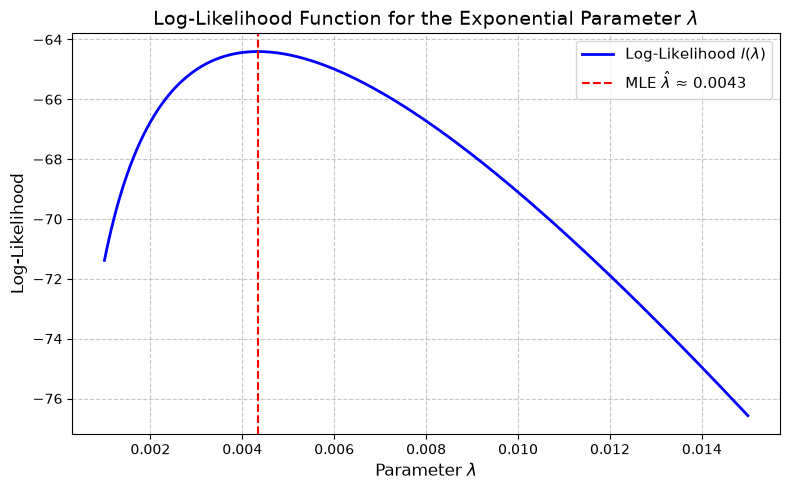

Sample sum: 2305
Sample mean (Expected working hours): 230.5
Estimated lambda: 0.00434


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Data from the example
data = np.array([142, 28, 606, 95, 12, 310, 45, 890, 115, 62])
n = len(data)
sum_x = np.sum(data)

# The log-likelihood function
def log_likelihood(lam):
    return n * np.log(lam) - lam * sum_x

# MLE for lambda
lambda_hat = n / sum_x
expected_hours = 1 / lambda_hat

# Create a range of lambda values around the MLE
lam_values = np.linspace(0.001, 0.015, 400)
ll_values = log_likelihood(lam_values)

# Plotting the log-likelihood
plt.figure(figsize=(8, 5))
plt.plot(lam_values, ll_values, label='Log-Likelihood $l(\lambda)$', color='blue', linewidth=2)
plt.axvline(x=lambda_hat, color='red', linestyle='--', label=f'MLE $\hat{{\lambda}}$ ≈ {lambda_hat:.4f}')

# Styling the plot
plt.title('Log-Likelihood Function for the Exponential Parameter $\lambda$', fontsize=14)
plt.xlabel('Parameter $\lambda$', fontsize=12)
plt.ylabel('Log-Likelihood', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Sample sum: {sum_x}")
print(f"Sample mean (Expected working hours): {expected_hours:.1f}")
print(f"Estimated lambda: {lambda_hat:.5f}")


## 4\. Unbiasedness and Reparametrization

Let's discuss whether our Maximum Likelihood Estimator for the Exponential distribution is an [Unbiased Estimator](statistical-inference.ipynb#unbiasedness).

In our previous example, we used the parameterization $X \sim \text{Expo}(\lambda)$, where $f(x; \lambda) = \lambda e^{-\lambda x}$ and $E[X] = \frac{1}{\lambda}$. We found that the MLE for $\lambda$ is:
$$ \hat{\lambda} = \frac{1}{\bar{X}} = \frac{n}{\sum_{i=1}^n X_i} $$

To check for unbiasedness, we must evaluate $E[\hat{\lambda}]$. The sum of $n$ independent Exponential random variables $\sum X_i$ follows a [Gamma distribution](gamma-function-and-distribution.ipynb#the-gamma-distribution) with shape $n$ and rate $\lambda$. It can be shown that the expected value of the inverse of this Gamma random variable is $\frac{\lambda}{n-1}$. Therefore:
$$ E[\hat{\lambda}] = E\left[ \frac{n}{\sum_{i=1}^n X_i} \right] = n \left( \frac{\lambda}{n-1} \right) = \frac{n}{n-1} \lambda \neq \lambda $$

Since $E[\hat{\lambda}] \neq \lambda$, our estimator $\hat{\lambda}$ is **biased**.

### Reparametrization

Now, let's use a different parameterization. Let $\theta = \frac{1}{\lambda}$. This makes $\theta$ the scale parameter, which is exactly the expected value: $E[X] = \theta$. The probability density function becomes:
$$ f(x; \theta) = \frac{1}{\theta} e^{-x/\theta} $$

::: {.callout-tip collapse="true"}
## Solution: Proving Unbiasedness for $\theta$

If we solve for the MLE under this new parameterization, we find that the MLE for $\theta$ is simply the sample mean:
$$ T = \hat{\theta} = \bar{X} = \frac{1}{n} \sum_{i=1}^n X_i $$

Let's prove this is an unbiased estimator by calculating its expected value $E[T]$:

**Step 1: Substitute the statistic $T$ into the expectation operator.**
$$ E[T] = E\left[ \frac{1}{n} \sum_{i=1}^n X_i \right] $$

**Step 2: Apply the linearity of expectation.**
The expectation of a sum is the sum of the expectations, and constants (like $\frac{1}{n}$) can be pulled outside:
$$ E[T] = \frac{1}{n} \sum_{i=1}^n E[X_i] $$

**Step 3: Substitute the expected value of the individual random variables.**
Because all observations in the [random sample](statistical-inference.ipynb#random-sample) are identically distributed, every individual $X_i$ has the same expected value, $E[X_i] = \theta$:
$$ E[T] = \frac{1}{n} \sum_{i=1}^n (\theta) $$

**Step 4: Evaluate the sum.**
Summing the constant $\theta$ a total of $n$ times gives us $n\theta$:
$$ E[T] = \frac{1}{n} (n\theta) $$

**Step 5: Simplify.**
$$ E[T] = \theta $$

**Conclusion:**
Because we have mathematically shown that $E[\hat{\theta}] = \theta$, our statistic exactly satisfies the definition of an unbiased estimator. Therefore, under the $\theta$ parameterization, the MLE is perfectly **unbiased**.
:::

::: {.callout-warning}
## Important Note on MLE and Unbiasedness
This example illustrates a crucial property of Maximum Likelihood Estimators:

1. **Invariance:** MLEs are invariant under reparametrization. If $\hat{\lambda}$ is the MLE for $\lambda$, then the MLE for $\theta = \frac{1}{\lambda}$ is exactly $\hat{\theta} = \frac{1}{\hat{\lambda}}$.
2. **Biasedness is NOT Invariant:** An unbiased estimator transformed by a non-linear function generally becomes biased. Thus, while $\hat{\theta}$ is unbiased for $\theta$, the transformed estimator $\hat{\lambda} = \frac{1}{\hat{\theta}}$ is biased for $\lambda$.
:::